# 13 · CFTR2 as the benchmark — which variants can *any* tool actually predict?

The `tools/` and `benchmark/` notebooks each introduced one tool in isolation. This notebook does the thing
those notebooks set up but never finish: take the **entire public CFTR2 variant list**
as the benchmark, run **every predictor in this toolkit** against it, and answer one
blunt question —

> **For how many real CF variants does a useful prediction even exist?**

That question has two answers, and the gap between them is the point of the notebook:

| | | |
|---|---|---|
| **Does a score exist?** | a tool returned a number | §5 — 90% of CFTR2 |
| **Does it address the mechanism?** | the tool speaks to *why this variant breaks CFTR* | §7 — 55% of CFTR2 |

Everything is written to `outputs/` at the end (§11).


> ✅ **REAL data throughout.** CFTR2 30 January 2026 (2,097 variants) · AlphaMissense ·
> EVE · ESM1b · REVEL v1.3 · PrimateAI · **SpliceAI v1.3** (~2.08 M CFTR records: 566 k
> masked SNVs + 1.51 M raw indels) · **Pangolin run locally over the whole CFTR2 list**
> (`build_pangolin.py`, ~1,892 scored, SNVs *and* indels) · live CADD v1.7 API.
> The SpliceAI extract is **mixed masked/raw** — rows carry `score_type`; see tools/07.
> Every extract is gitignored; rebuild with the
> `build_*.py` scripts (see `data/README.md`). If an extract is missing, that tool's
> column is simply empty here — the notebook still runs, but the coverage numbers will be
> wrong.


In [1]:
import sys, pathlib, warnings, re
# `toolkit` is THIS repo's toolkit.py (one directory up) — predict/ sits beside
# tools/ and benchmark/, so the same sys.path line works here.
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import toolkit as tk
import pandas as pd, numpy as np
# %matplotlib inline is a Jupyter magic: it draws matplotlib plots inline below the cell
%matplotlib inline

OUT_DIR = tk.OUT_DIR                 # <repo>/outputs — gitignored, regenerated by this notebook
OUT_DIR.mkdir(exist_ok=True)
pd.set_option("display.width", 160)
print("results will be written to:", OUT_DIR)

results will be written to: E:\cftr_variant_toolkit\outputs


## 1 · Why CFTR2 is the right benchmark here — and where it is weak

CFTR2 is the **disease-specific** reference (benchmark/01): it labels *CFTR* variants using
**patient outcomes + in-vitro CFTR function assays**. The functional axis is evidence a
sequence model never trained on, which is why it is a better yardstick than ClinVar alone.

Three honest caveats, stated up front because they bound everything below:

1. **Not independent of ClinVar.** CFTR2 and ClinVar share clinical evidence and cross-cite,
   and **REVEL is trained on ClinVar-lineage labels** — so REVEL's numbers here are
   **partly circular** (tools/10). Treat the unsupervised tools (AlphaMissense, EVE,
   ESM1b) as the cleaner comparison.
2. **Brutal class imbalance.** CFTR2 has ~1,245 *CF-causing* variants and only ~42
   *Non CF-causing* ones. Specificity is therefore estimated from a few dozen variants and
   is *noisy*; accuracy on this set is close to meaningless.
3. **"No interpretation available" is not "benign".** ~722 variants carry that label —
   they are excluded from the accuracy math but kept in the coverage math, because *those*
   are exactly the variants a predictor would be useful for.


In [2]:
cftr2 = tk.load_cftr2()          # REAL — the full 30 January 2026 release
print(f"CFTR2 variants: {len(cftr2):,} | source: {cftr2['source'].unique().tolist()}")
print()
print(cftr2["cftr2_class"].value_counts(dropna=False).to_string())

CFTR2 variants: 2,097 | source: ['REAL']

cftr2_class
CF-causing                      1245
No interpretation available      722
Varying clinical consequence      83
Non CF-causing                    42
NaN                                5


## 2 · Annotate what each variant *is*

Coverage only makes sense against variant class: a missense predictor missing a whole-exon
deletion is not a bug. `build_cftr2.py` already derives a 1-letter `protein_variant` key for
simple missense; here we classify **every** row from its HGVS protein/cDNA name so we can
read the coverage table by class.

Order matters — `del/ins/dup` is tested first because a variant like
`c.2916_2917delinsAT` also carries a missense-looking protein name.


In [3]:
def variant_class(row) -> str:
    """Coarse class from the HGVS names. Checked in order — indel first, because a
    delins can also look like a missense at the protein level."""
    p, c = str(row.get("protein_name") or ""), str(row.get("cdna_name") or "")
    if re.search(r"(del|ins|dup)", c):                     return "indel / large del"
    if "X" in p:                                           return "nonsense"
    if re.match(r"^p\.[A-Z][a-z]{2}\d+[A-Z][a-z]{2}$", p): return "missense"
    if "=" in p:                                           return "synonymous"
    if re.search(r"c\.[\d*-]+[+-]\d+", c):                 return "intronic / splice-region"
    if re.match(r"^c\.-", c):                              return "5' UTR"
    if re.match(r"^c\.\*", c):                             return "3' UTR"
    return "other / complex"

bench = cftr2.copy()
bench["protein_variant"] = bench["protein_variant"].fillna("")
bench["variant_class"]   = bench.apply(variant_class, axis=1)
print(bench["variant_class"].value_counts().to_string())

variant_class
missense                    778
indel / large del           713
intronic / splice-region    270
nonsense                    224
other / complex              62
synonymous                   41
5' UTR                        9


## 3 · Three join keys, one benchmark table

The tools do **not** share an identifier, and this is the single biggest practical obstacle
to a cross-tool comparison:

| Key | Tools | Consequence |
|---|---|---|
| **protein change** (`G551D`) | AlphaMissense, EVE, ESM1b | only exists for simple missense (~780 / 2,097) |
| **genomic coordinate** (`7-117587778-G-T`) | REVEL, PrimateAI, SpliceAI | needs CFTR2's GRCh38 columns — **204 variants have none** |
| **cDNA name** (`c.3718-2477C>T`) | Pangolin (as built here) | the only key that covers every variant class |

CFTR2's GRCh38 coordinates are the authoritative ones (tools/07 showed the demo table's
hand-entered coords mostly don't reproduce), so we join on those rather than re-deriving them.

**Both splice tools now score indels**, which is what lets them reach variant classes no
missense predictor can touch. SpliceAI's indels come from Illumina's precomputed
`raw.indel` release (1.51 M CFTR records — `masked.indel` is commonly a 0-byte failed
download, so the extract is mixed masked/raw; see tools/07). Pangolin has no precomputed
release at all, so `build_pangolin.py` runs the model locally over every CFTR2 variant with
coordinates. §7 and §8 are about whether that reach is worth anything.


In [4]:
bench["chrom"] = "7"
bench["pos"]   = pd.to_numeric(bench["grch38_pos"], errors="coerce")
bench["ref"]   = bench["grch38_ref"].astype("string")
bench["alt"]   = bench["grch38_alt"].astype("string")

def join_protein(frame, loader, col, out):
    """Join a protein-keyed tool. Rows with no missense key get NaN, never a stray match."""
    d = loader()[["protein_variant", col]].dropna(subset=["protein_variant"])
    d = d.drop_duplicates("protein_variant").rename(columns={col: out})
    frame = frame.merge(d, on="protein_variant", how="left")
    frame.loc[frame["protein_variant"] == "", out] = np.nan
    return frame

def join_coord(frame, loader, col, out):
    """Join a coordinate-keyed tool on chrom/pos/ref/alt (GRCh38, from CFTR2)."""
    d = loader()[["chrom", "pos", "ref", "alt", col]].copy()
    d["chrom"] = d["chrom"].astype(str)
    d["pos"]   = pd.to_numeric(d["pos"], errors="coerce")
    d["ref"], d["alt"] = d["ref"].astype("string"), d["alt"].astype("string")
    d = d.drop_duplicates(["chrom", "pos", "ref", "alt"]).rename(columns={col: out})
    return frame.merge(d, on=["chrom", "pos", "ref", "alt"], how="left")

bench = join_protein(bench, tk.load_alphamissense, "am_score",    "AlphaMissense")
bench = join_protein(bench, tk.load_eve,           "eve_score",   "EVE")
bench = join_protein(bench, tk.load_esm1b,         "esm1b_score", "ESM1b")
bench = join_coord(bench,   tk.load_revel,         "revel_score",      "REVEL")
bench = join_coord(bench,   tk.load_primateai,     "primate_ai_score", "PrimateAI")
bench = join_coord(bench,   tk.load_spliceai,      "spliceai_ds_max",  "SpliceAI")

# Pangolin: cDNA-keyed, run locally over the whole CFTR2 list by build_pangolin.py.
pg = tk.load_pangolin()
print(f"Pangolin: {int(pg['pangolin_score'].notna().sum()):,} scored / {len(pg):,} targets "
      f"| source: {pg['source'].unique().tolist()}")
if "skip_reason" in pg and pg["pangolin_score"].isna().any():
    print(pg.loc[pg["pangolin_score"].isna(), "skip_reason"].value_counts().to_string())
bench = bench.merge(pg[["cdna_name", "pangolin_score"]].drop_duplicates("cdna_name")
                      .rename(columns={"pangolin_score": "Pangolin"}),
                    on="cdna_name", how="left")

MISSENSE_TOOLS = ["AlphaMissense", "EVE", "ESM1b", "REVEL", "PrimateAI"]
SPLICE_TOOLS   = ["SpliceAI", "Pangolin"]
ALL_TOOLS      = MISSENSE_TOOLS + SPLICE_TOOLS
print(f"\nbenchmark table: {bench.shape[0]:,} variants x {bench.shape[1]} columns")

Pangolin: 1,892 scored / 2,097 targets | source: ['REAL']
skip_reason
no GRCh38 coordinates in CFTR2    204
event larger than 100 bp            1

benchmark table: 2,097 variants x 25 columns


### The one variant the protein key silently loses

780 CFTR2 variants carry a 1-letter missense key; **779** find an AlphaMissense score. The
miss is **M470V**, and the reason is worth more than the one row it costs.

CFTR2 names the polymorphism relative to the MANE transcript, where the reference residue is
**M**470. AlphaMissense is keyed on the UniProt P13569 canonical sequence, where the reference
residue is **V**470 — so AlphaMissense lists the *opposite* substitution, `V470M`. Same
polymorphism, reversed polarity, and a string join has no way to notice.


In [5]:
am = tk.load_alphamissense()
print("CFTR2 asks for M470V →", (am["protein_variant"] == "M470V").sum(), "AlphaMissense rows")
print("AlphaMissense has the reverse, V470M →")
print(am[am["protein_variant"] == "V470M"].to_string(index=False))
print("\nCFTR2's own row (note: no GRCh38 coordinates either, so the coord join can't rescue it):")
print(bench.loc[bench["legacy_name"] == "M470V",
                ["legacy_name", "cdna_name", "protein_name", "cftr2_class",
                 "grch38_pos", "AlphaMissense", "REVEL"]].to_string(index=False))

CFTR2 asks for M470V → 0 AlphaMissense rows
AlphaMissense has the reverse, V470M →
protein_variant  am_score am_class                    am_release source
          V470M    0.0489   benign Tue, 19 Sep 2023 12:02:53 GMT   REAL

CFTR2's own row (note: no GRCh38 coordinates either, so the coord join can't rescue it):
legacy_name cdna_name protein_name    cftr2_class  grch38_pos  AlphaMissense  REVEL
      M470V c.1408A>G  p.Met470Val Non CF-causing         NaN            NaN    NaN


## 4 · Per-tool coverage over the whole CFTR2 list

In [6]:
cov = pd.DataFrame({
    "tool":     ALL_TOOLS,
    "kind":     ["missense"] * len(MISSENSE_TOOLS) + ["splice"] * len(SPLICE_TOOLS),
    "join_key": ["protein", "protein", "protein", "coordinate", "coordinate",
                 "coordinate", "cDNA name"],
    "scored":   [int(bench[t].notna().sum()) for t in ALL_TOOLS],
})
cov["pct_of_cftr2"] = (100 * cov["scored"] / len(bench)).round(1)
cov["learning"]     = [tk.TOOL_REGISTRY[t]["learning"] for t in ALL_TOOLS]
cov.sort_values("scored", ascending=False, ignore_index=True)

,tool,kind,join_key,scored,pct_of_cftr2,learning
0,Pangolin,splice,cDNA name,1892,90.2,supervised (on splice usage across species/tis...
1,SpliceAI,splice,coordinate,1728,82.4,"supervised (on GTEx splice junctions, not clin..."
2,REVEL,missense,coordinate,783,37.3,supervised
3,AlphaMissense,missense,protein,779,37.1,unsupervised
4,ESM1b,missense,protein,779,37.1,unsupervised
5,PrimateAI,missense,coordinate,777,37.1,semi-supervised
6,EVE,missense,protein,764,36.4,unsupervised


Two things to notice, both of which are about *plumbing* rather than model quality:

- **The splice tools cover 4-6× more of CFTR2 than any missense tool** (Pangolin 1,892,
  SpliceAI 1,728) — not because they are better models, but because they score indels and
  every variant class, while a missense predictor structurally cannot leave its own domain.
  Pangolin edges ahead only because a local run has no distribution gaps; SpliceAI's 1,728
  is bounded by which variants Illumina precomputed, not by what SpliceAI can do.
- **REVEL scores 801 but AlphaMissense only 779.** REVEL is coordinate-keyed, so it picks up
  rows whose protein key CFTR2 never derived (multi-allelic `c.` names, delins). §8 shows what
  those extra scores are actually worth.


## 5 · The three parts

The categories are **mutually exclusive and ordered**: a variant goes to *missense tools* if
any missense predictor scores it, otherwise to *splice tools only* if a splice predictor
does, otherwise to *no tool*. The ordering matters because the splice tools between them
score essentially every variant with coordinates — without it, the "splice" bucket would
swallow most of the missense set (the overlap is printed below).


In [7]:
bench["n_missense_tools"] = bench[MISSENSE_TOOLS].notna().sum(axis=1)
bench["n_splice_tools"]   = bench[SPLICE_TOOLS].notna().sum(axis=1)
bench["category"] = np.select(
    [bench["n_missense_tools"] >= 1, bench["n_splice_tools"] >= 1],
    ["1. missense tools", "2. splice tools only"],
    default="3. no tool")

n = len(bench)
for cat, cnt in bench["category"].value_counts().sort_index().items():
    print(f"{cat:24s} {cnt:5,d}  ({100*cnt/n:4.1f}%)")
print(f"{'TOTAL':24s} {n:5,d}")
print("\noverlap — scored by a missense tool AND a splice tool:",
      int(((bench.n_missense_tools >= 1) & (bench.n_splice_tools >= 1)).sum()))

1. missense tools          785  (37.4%)
2. splice tools only     1,107  (52.8%)
3. no tool                 205  ( 9.8%)
TOTAL                    2,097

overlap — scored by a missense tool AND a splice tool: 785


In [8]:
by_class = pd.crosstab(bench["variant_class"], bench["category"], margins=True, margins_name="TOTAL")
by_class

category,1. missense tools,2. splice tools only,3. no tool,TOTAL
variant_class,,,,
5' UTR,0,9,0,9
indel / large del,2,573,138,713
intronic / splice-region,0,268,2,270
missense,777,0,1,778
nonsense,0,215,9,224
other / complex,6,2,54,62
synonymous,0,40,1,41
TOTAL,785,1107,205,2097


In [9]:
by_truth = pd.crosstab(bench["cftr2_class"], bench["category"], margins=True, margins_name="TOTAL")
by_truth

category,1. missense tools,2. splice tools only,3. no tool,TOTAL
cftr2_class,,,,
CF-causing,265,869,111,1245
No interpretation available,414,224,84,722
Non CF-causing,33,6,3,42
Varying clinical consequence,73,8,2,83
TOTAL,785,1107,200,2092


**Only 205 variants (9.8%) have no score at all** — and 138 of those are deletions or
insertions, with the rest mostly complex alleles CFTR2 never gave coordinates to. Read
naively, that is a reassuring table: the toolkit covers ~90% of CFTR2.

Hold that thought until §7.


## 6 · Weight by how often the variant is actually *seen*

Variant counts treat F508del and a variant reported in one patient as equal. CFTR2 ships an
allele frequency (`cftr2_af`, the share of CF alleles in its patient cohort), so we can ask
the clinically honest version of the question: **what fraction of CF alleles walking through
a clinic carry a score?**


In [10]:
bench["cftr2_af"] = pd.to_numeric(bench["cftr2_af"], errors="coerce")
af = bench.dropna(subset=["cftr2_af"])
share = (af.groupby("category")["cftr2_af"].sum() / af["cftr2_af"].sum())
print("share of CF alleles (frequency-weighted), by category:")
for cat, v in share.sort_index().items():
    print(f"  {cat:24s} {100*v:5.1f}%")
print("\nthe single biggest allele, and what scores it:")
print(af.nlargest(3, "cftr2_af")[["legacy_name", "cdna_name", "variant_class",
                                  "SpliceAI", "Pangolin", "category"]].to_string(index=False))

share of CF alleles (frequency-weighted), by category:
  1. missense tools         12.9%
  2. splice tools only      84.8%
  3. no tool                 2.3%

the single biggest allele, and what scores it:
legacy_name      cdna_name     variant_class  SpliceAI  Pangolin             category
    F508del c.1521_1523del indel / large del      0.01    0.0518 2. splice tools only
      G542X      c.1624G>T          nonsense      0.13    0.0885 2. splice tools only
      G551D      c.1652G>A          missense      0.00    0.0115    1. missense tools


**F508del now has two scores.** Both splice tools reach it — SpliceAI **0.01** (from the
precomputed indel release) and Pangolin **0.05** (from the local run) — which lands it in
"splice tools only". Frequency-weighted, part 2 is now ~84% of CF alleles and the no-tool
bucket collapses to ~2%.

This looks like the toolkit just solved CF variant interpretation. It did not. **Both scores
mean "this variant does not disrupt splicing"** — which is completely correct, and completely
useless: F508del causes disease by making the protein misfold, and nothing in this toolkit
measures folding. Two independent models agreeing on the right answer to the wrong question
is still no answer.


## 7 · ★ The honest question: does any tool address the *mechanism*?

"A score exists" is the wrong bar. The right one is **does some tool speak to the reason
this particular variant breaks CFTR?** A splice model has something to say about an intronic
variant; on a frameshift it can only tell you the frameshift does not *also* break splicing.

So we re-score coverage by mechanism:

| Variant class | Addressed when… |
|---|---|
| missense | a missense predictor scores it |
| intronic / splice-region / synonymous / UTR | a splice predictor scores it |
| nonsense, indel, complex | **only** if a splice tool actually flags disruption (≥ 0.5) — i.e. splicing is a plausible mechanism after all |

Everything else is **unaddressed**: a number exists, but no tool here models what is
actually wrong. Nonsense and frameshift variants need loss-of-function / NMD reasoning,
which this toolkit has none of.


In [11]:
MISSENSE_DOMAIN = ["missense"]
SPLICE_DOMAIN   = ["intronic / splice-region", "synonymous", "5' UTR", "3' UTR"]
SPLICE_CUT      = tk.THRESHOLDS["spliceai"]["high"]      # 0.5 = HIGH impact

def mechanism(row) -> str:
    """Is there a tool here that speaks to WHY this variant breaks CFTR?"""
    if row["variant_class"] in MISSENSE_DOMAIN and row["n_missense_tools"] >= 1:
        return "yes - missense tool"
    if row["variant_class"] in SPLICE_DOMAIN and row["n_splice_tools"] >= 1:
        return "yes - splice tool"
    # nonsense / indel / complex: only if a splice tool actually calls disruption
    splice_scores = [s for s in (row["SpliceAI"], row["Pangolin"]) if pd.notna(s)]
    if splice_scores and max(splice_scores) >= SPLICE_CUT:
        return "yes - splice tool (flags disruption)"
    return "NO - mechanism unaddressed"

bench["mechanism"] = bench.apply(mechanism, axis=1)
print(bench["mechanism"].value_counts().to_string())
unaddressed = bench["mechanism"].str.startswith("NO")
print(f"\nmechanism unaddressed: {int(unaddressed.sum()):,} / {len(bench):,} "
      f"({100*unaddressed.mean():.1f}%)")
print(f"  ... of which have a score anyway: "
      f"{int((unaddressed & (bench[ALL_TOOLS].notna().any(axis=1))).sum()):,}")

mechanism
NO - mechanism unaddressed              951
yes - missense tool                     777
yes - splice tool                       317
yes - splice tool (flags disruption)     52

mechanism unaddressed: 951 / 2,097 (45.4%)
  ... of which have a score anyway: 746


In [12]:
pd.crosstab(bench["variant_class"], bench["mechanism"], margins=True, margins_name="TOTAL")

mechanism,NO - mechanism unaddressed,yes - missense tool,yes - splice tool,yes - splice tool (flags disruption),TOTAL
variant_class,,,,,
5' UTR,0,0,9,0,9
indel / large del,676,0,0,37,713
intronic / splice-region,2,0,268,0,270
missense,1,777,0,0,778
nonsense,211,0,0,13,224
other / complex,60,0,0,2,62
synonymous,1,0,40,0,41
TOTAL,951,777,317,52,2097


In [13]:
af = bench.dropna(subset=["cftr2_af"])     # refreshed — bench gained `mechanism` above
w = af.groupby(af["mechanism"].str.startswith("NO"))["cftr2_af"].sum() / af["cftr2_af"].sum()
print("CF alleles (frequency-weighted) whose mechanism NO tool here addresses: "
      f"{100*w.get(True, 0):.1f}%")
cf_causing = bench[bench["cftr2_class"] == "CF-causing"]
print(f"CF-causing variants with mechanism unaddressed: "
      f"{int(cf_causing['mechanism'].str.startswith('NO').sum()):,} / {len(cf_causing):,}")

CF alleles (frequency-weighted) whose mechanism NO tool here addresses: 79.9%
CF-causing variants with mechanism unaddressed: 788 / 1,245


### This is the result

Counted by variant, **951 of 2,097 (45%)** have no tool addressing their mechanism — and
**746 of those carry a score anyway**. Weighted by allele frequency it is **~80% of CF
alleles**, and **788 of 1,245 CF-causing variants**.

Compare the two framings of the same data:

| | no score exists | mechanism unaddressed |
|---|---|---|
| by variant | 205 (9.8%) | **951 (45.4%)** |
| by CF allele frequency | 2.3% | **79.9%** |

Adding SpliceAI's indel release and running Pangolin locally moved ~580 indels out of the
"no score" bucket and only **52** into "mechanism addressed". **The gap between those two
rows is the honest description of this toolkit** — and it is a gap no additional splice or
missense model closes, because the missing mechanism is protein folding and
nonsense-mediated decay.


## 8 · Coverage is not competence

Two concrete demonstrations that a score existing means nothing on its own:

- **Both splice tools score most CFTR2 indels and call almost none of them HIGH.** Pangolin
  scores 575 of the 713 (35 HIGH); SpliceAI scores 417 (22 HIGH). Median score on CF-causing
  indels: **0.05** and **0.03**.
  On the indels carrying a CFTR2 truth label their sensitivity is **0.05 and 0.04** — they
  miss 478 of 505 and 365 of 380 CF-causing indels respectively. As splice biology that is
  *correct*. As a pathogenicity signal it is noise: these are frameshifts that destroy the
  protein by a route neither model represents. Two independent models agreeing here is not
  reassurance — they agree because they are both answering a question that isn't the one
  being asked.
- **REVEL scores 12 nonsense variants.** REVEL is a missense ensemble; these are stop-gains
  that truncate the protein. The scores run 0.009 → 0.86 — i.e. mostly "benign" for variants
  that are unambiguously CF-causing. They arrive because dbNSFP carries the substitution as
  missense on *some* transcript, and our coordinate join is transcript-blind.

§9 therefore reports metrics **twice**: naively over everything a tool scored, and restricted
to the variant classes the tool is actually *for*.


In [14]:
indels = bench[bench["variant_class"] == "indel / large del"]
for tool in SPLICE_TOOLS:
    d = indels.dropna(subset=[tool])
    cfc = d.loc[d.cftr2_class == "CF-causing", tool]
    print(f"{tool:9s} scores {len(d):3,} of the {len(indels):,} CFTR2 indels | "
          f"HIGH: {int((d[tool] >= SPLICE_CUT).sum()):3,} | "
          f"median on CF-causing indels: {cfc.median():.4f}")
print()
bad_revel = bench[(bench["variant_class"] == "nonsense") & bench["REVEL"].notna()]
print(f"nonsense variants carrying a REVEL score: {len(bad_revel)}\n")
print(bad_revel[["legacy_name", "cdna_name", "protein_name", "cftr2_class", "REVEL"]]
      .sort_values("REVEL").to_string(index=False))

SpliceAI  scores 417 of the 713 CFTR2 indels | HIGH:  22 | median on CF-causing indels: 0.0300
Pangolin  scores 575 of the 713 CFTR2 indels | HIGH:  35 | median on CF-causing indels: 0.0525

nonsense variants carrying a REVEL score: 0

Empty DataFrame
Columns: [legacy_name, cdna_name, protein_name, cftr2_class, REVEL]
Index: []


## 9 · The benchmark itself

Truth set = the CFTR2 variants with a *decided* call: **CF-causing** (positive) vs
**Non CF-causing** (negative). "Varying clinical consequence" and "No interpretation
available" are excluded — they are not benign, and scoring them as such would manufacture
false positives.

Thresholds come from `tk.THRESHOLDS` (each tool's own published cut-point), so the
comparison is "each tool at its recommended operating point", not a re-tuned one.


In [15]:
truth = bench[bench["cftr2_class"].isin(["CF-causing", "Non CF-causing"])].copy()
truth["y"] = (truth["cftr2_class"] == "CF-causing").astype(int)
print(f"truth set: {len(truth):,} variants | CF-causing: {int(truth.y.sum()):,} "
      f"| Non CF-causing: {int((1-truth.y).sum())}")

TOOL_KEY = {"AlphaMissense": "am", "EVE": "eve", "ESM1b": "esm1b",
            "REVEL": "revel", "PrimateAI": "primate_ai"}

def flag_pathogenic(frame, tool):
    """Binary 'this tool calls it damaging', at the tool's own published cut-point."""
    if tool in TOOL_KEY:
        return frame[tool].apply(lambda s: tk.call_from_score(s, TOOL_KEY[tool]) == "pathogenic")
    return frame[tool] >= SPLICE_CUT

def metrics(frame, tool, label):
    d = frame.dropna(subset=[tool])
    if d.empty:
        return dict(tool=tool, domain=label, n=0)
    pred = flag_pathogenic(d, tool)
    tp = int((pred & (d.y == 1)).sum()); fp = int((pred & (d.y == 0)).sum())
    fn = int((~pred & (d.y == 1)).sum()); tn = int((~pred & (d.y == 0)).sum())
    return dict(tool=tool, domain=label, n=len(d), TP=tp, FP=fp, FN=fn, TN=tn,
                sensitivity=round(tp / (tp + fn), 3) if tp + fn else np.nan,
                specificity=round(tn / (tn + fp), 3) if tn + fp else np.nan)

naive = pd.DataFrame([metrics(truth, t, "everything it scored") for t in ALL_TOOLS])
naive

truth set: 1,287 variants | CF-causing: 1,245 | Non CF-causing: 42


,tool,domain,n,TP,FP,FN,TN,sensitivity,specificity
0,AlphaMissense,everything it scored,292,243,6,16,27,0.938,0.818
1,EVE,everything it scored,291,253,20,5,13,0.981,0.394
2,ESM1b,everything it scored,292,239,9,20,24,0.923,0.727
3,REVEL,everything it scored,298,235,11,30,22,0.887,0.667
4,PrimateAI,everything it scored,292,50,0,209,33,0.193,1.000
5,SpliceAI,everything it scored,1047,182,0,827,38,0.180,1.000
6,Pangolin,everything it scored,1173,191,0,943,39,0.168,1.000


Now the same tools, each restricted to its own domain — missense predictors on missense
variants, splice predictors on non-coding/synonymous variants — plus, for contrast, the
splice tools on indels, where they have coverage but no claim to competence.


In [16]:
mis_truth = truth[truth["variant_class"].isin(MISSENSE_DOMAIN)]
spl_truth = truth[truth["variant_class"].isin(SPLICE_DOMAIN)]
ind_truth = truth[truth["variant_class"] == "indel / large del"]
print(f"missense domain: {len(mis_truth):3d} variants ({int(mis_truth.y.sum())} CF-causing / "
      f"{int((1-mis_truth.y).sum())} not)")
print(f"splice domain:   {len(spl_truth):3d} variants ({int(spl_truth.y.sum())} CF-causing / "
      f"{int((1-spl_truth.y).sum())} not)")
print(f"indels:          {len(ind_truth):3d} variants ({int(ind_truth.y.sum())} CF-causing / "
      f"{int((1-ind_truth.y).sum())} not)  <- out of domain for every tool here")

perf = pd.DataFrame(
    [metrics(mis_truth, t, "missense only")   for t in MISSENSE_TOOLS] +
    [metrics(spl_truth, t, "non-coding only") for t in SPLICE_TOOLS] +
    [metrics(ind_truth, t, "indels (out of domain)") for t in SPLICE_TOOLS])
perf

missense domain: 293 variants (259 CF-causing / 34 not)
splice domain:   158 variants (154 CF-causing / 4 not)
indels:          612 variants (610 CF-causing / 2 not)  <- out of domain for every tool here


,tool,domain,n,TP,FP,FN,TN,sensitivity,specificity
0,AlphaMissense,missense only,292,243,6,16,27,0.938,0.818
1,EVE,missense only,291,253,20,5,13,0.981,0.394
2,ESM1b,missense only,292,239,9,20,24,0.923,0.727
3,REVEL,missense only,292,235,11,24,22,0.907,0.667
4,PrimateAI,missense only,292,50,0,209,33,0.193,1.000
5,SpliceAI,non-coding only,158,149,0,5,4,0.968,1.000
6,Pangolin,non-coding only,158,146,0,8,4,0.948,1.000
7,SpliceAI,indels (out of domain),381,15,0,365,1,0.039,1.000
8,Pangolin,indels (out of domain),507,27,0,478,2,0.053,1.000


### Reading this table honestly

- **The splice tools are the standout — in their own domain.** SpliceAI ~0.97 and Pangolin
  ~0.95 sensitivity on non-coding variants, versus **0.18 / 0.17** when judged on everything
  they happened to score, and **0.04 / 0.05** on indels. Same models, same thresholds, same
  day — a 20-fold swing driven entirely by which variants you let into the denominator. The
  domain row is the result; the other two are measurement artefacts.
- **AlphaMissense has the best missense balance** (~0.94 sens / ~0.82 spec) and is
  label-unsupervised, so it is the least circular of the five.
- **EVE catches nearly everything but calls almost everything damaging** — high sensitivity,
  ~0.39 specificity. On a VUS list that is a lot of false alarms.
- **REVEL's numbers are the least trustworthy here** — not because they look bad, but because
  REVEL is trained on ClinVar-lineage labels that CFTR2 correlates with (tools/10). It is
  partly grading its own homework.
- **PrimateAI looks broken and isn't.** Its published cut-point (0.803) is far above where its
  CF-causing scores actually sit (median ~0.72), so it calls ~80% of true CF variants benign at
  that threshold. It is a *threshold* mismatch on this gene, not a scoring failure — the
  distribution below makes that visible, and it is exactly why graded, gene-aware thresholds
  (Pejaver 2022) beat one global cut.
- **Specificity everywhere rests on ≤ 34 negatives.** Do not rank tools by it.


### The payoff of running Pangolin ourselves: two independent models that agree

Coverage was the *wrong* reason to run Pangolin at scale. This is the right one — SpliceAI
and Pangolin were built independently, so where both score a non-coding variant, their
agreement is stronger evidence than either alone (tools/08). Now that Pangolin covers the
whole list instead of 5 alleles, that agreement can actually be measured.


In [17]:
both = bench[bench["variant_class"].isin(SPLICE_DOMAIN)].dropna(subset=["SpliceAI", "Pangolin"])
hi_s, hi_p = both["SpliceAI"] >= SPLICE_CUT, both["Pangolin"] >= SPLICE_CUT
print(f"non-coding variants scored by BOTH: {len(both):,}")
print(f"  both HIGH:  {int((hi_s & hi_p).sum()):,}")
print(f"  both LOW:   {int((~hi_s & ~hi_p).sum()):,}")
print(f"  disagree:   {int((hi_s ^ hi_p).sum()):,}")
print(f"  Pearson r:  {both['SpliceAI'].corr(both['Pangolin']):.3f}")

non-coding variants scored by BOTH: 311
  both HIGH:  182
  both LOW:   117
  disagree:   12
  Pearson r:  0.976


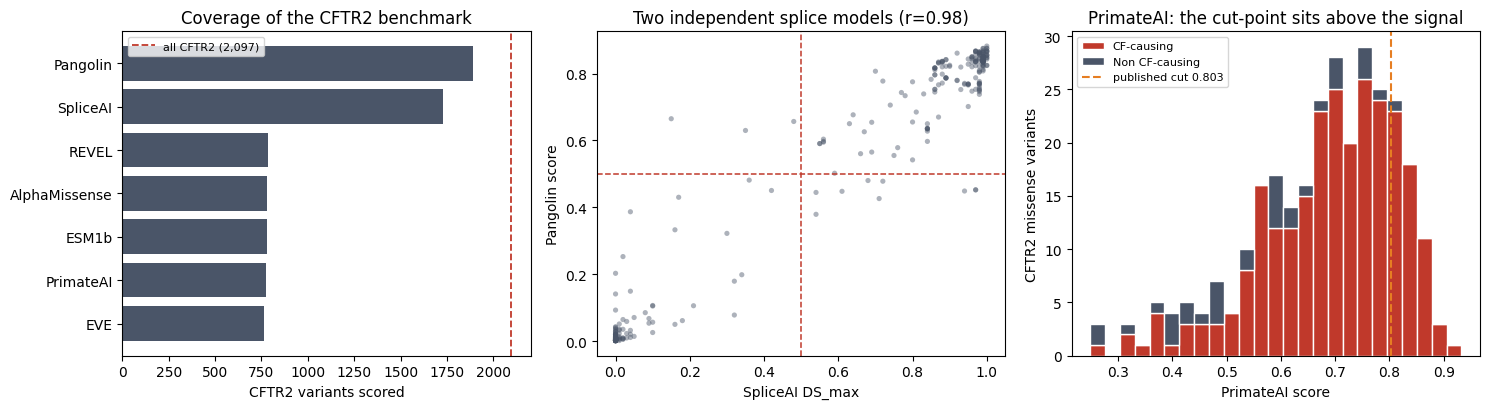

In [18]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

order = cov.sort_values("scored")["tool"]
axes[0].barh(order, [int(bench[t].notna().sum()) for t in order], color="#4a5568")
axes[0].axvline(len(bench), ls="--", color="#c0392b", lw=1.3, label=f"all CFTR2 ({len(bench):,})")
axes[0].set_xlabel("CFTR2 variants scored"); axes[0].set_title("Coverage of the CFTR2 benchmark")
axes[0].legend(fontsize=8)

axes[1].scatter(both["SpliceAI"], both["Pangolin"], s=14, alpha=0.45, color="#4a5568",
                edgecolors="none")
axes[1].axvline(SPLICE_CUT, ls="--", color="#c0392b", lw=1.1)
axes[1].axhline(SPLICE_CUT, ls="--", color="#c0392b", lw=1.1)
axes[1].set_xlabel("SpliceAI DS_max"); axes[1].set_ylabel("Pangolin score")
axes[1].set_title(f"Two independent splice models (r={both['SpliceAI'].corr(both['Pangolin']):.2f})")

d = mis_truth.dropna(subset=["PrimateAI"])
axes[2].hist([d.loc[d.y == 1, "PrimateAI"], d.loc[d.y == 0, "PrimateAI"]], bins=25,
             stacked=True, color=["#c0392b", "#4a5568"], edgecolor="white",
             label=["CF-causing", "Non CF-causing"])
axes[2].axvline(tk.THRESHOLDS["primate_ai"]["path"], ls="--", color="#e67e22", lw=1.5,
                label="published cut 0.803")
axes[2].set_xlabel("PrimateAI score"); axes[2].set_ylabel("CFTR2 missense variants")
axes[2].set_title("PrimateAI: the cut-point sits above the signal"); axes[2].legend(fontsize=8)

fig.tight_layout()
fig.savefig(OUT_DIR / "predict_coverage.png", dpi=150)
plt.show()

## 10 · Can CADD reach what is left?

CADD is the one general-purpose scorer in the toolkit — not restricted to missense or to
splicing. It is the obvious candidate for the 205 variants nothing else scores. It reaches
**none of them**: the CADD REST API returns substitutions, and after the local Pangolin run
every remaining uncovered variant is an indel, a complex allele, or has no CFTR2 coordinates
at all.

This is a **live API** (tools/09), so the cell stays bounded and defensive — a network
failure degrades to empty rather than breaking the notebook.


In [19]:
uncovered = bench[bench["category"] == "3. no tool"].copy()
is_snv = (uncovered["ref"].str.len().eq(1) & uncovered["alt"].str.len().eq(1)).fillna(False)
rescuable = uncovered[is_snv]
print(f"uncovered variants: {len(uncovered):,}")
print(f"  ... with GRCh38 coordinates: {int(uncovered['pos'].notna().sum()):,}")
print(f"  ... and a single-nucleotide substitution CADD could score: {len(rescuable)}")
print("\nwhat the uncovered actually are:")
print(uncovered["variant_class"].value_counts().to_string())

# PLACEHOLDER -- this notebook has not been audited yet for the tools/ + benchmark/
# reorg. fetch_cadd() used to live in toolkit.py; it now lives in
# tools/09_cadd.ipynb (CADD needs no local file, so it makes a live API call per
# variant). What this loop is trying to do: for every CFTR2 variant that no other
# tool scores AND is a plain single-nucleotide substitution (`rescuable`), query
# CADD live and record its PHRED score, to see how many of the "no tool" gap
# variants CADD alone can still address. To restore it: import fetch_cadd from
# tools/09_cadd.ipynb (or re-add a thin wrapper here) and call it in the loop below.
rows = []
# for _, v in rescuable.iterrows():
#     r = fetch_cadd("7", int(v["pos"]), v["ref"], v["alt"])
#     rows.append({"legacy_name": v["legacy_name"], "cdna_name": v["cdna_name"],
#                  "variant_class": v["variant_class"], "cftr2_class": v["cftr2_class"],
#                  "cadd_phred": r.get("cadd_phred")})
cadd_rescue = pd.DataFrame(rows)
if cadd_rescue.empty:
    print("\n[pending audit -- CADD rescue loop disabled, see comment above] "
          "nothing for CADD to score -- the remaining gap is not a substitution problem.")
cadd_rescue

uncovered variants: 205
  ... with GRCh38 coordinates: 1
  ... and a single-nucleotide substitution CADD could score: 0

what the uncovered actually are:
variant_class
indel / large del           138
other / complex              54
nonsense                      9
intronic / splice-region      2
missense                      1
synonymous                    1

[pending audit -- CADD rescue loop disabled, see comment above] nothing for CADD to score -- the remaining gap is not a substitution problem.


""


**The remaining gap is not a tooling gap this toolkit can close.** Closing it needs a
different class of evidence entirely: functional assays, RNA studies, NMD prediction, or the
CFTR2 patient data itself.


## 11 · Write the results to `outputs/`

`outputs/` is gitignored (like `data/`), so these files are **regenerated, never committed** —
re-run this notebook to rebuild them. The notebook itself ships with its executed cells, so the
numbers stay readable without the data.


In [20]:
KEEP = ["legacy_name", "cdna_name", "protein_name", "protein_variant", "variant_class",
        "cftr2_class", "cftr2_af", "grch38_pos", "grch38_ref", "grch38_alt",
        *ALL_TOOLS, "n_missense_tools", "n_splice_tools", "category", "mechanism"]
master = bench[KEEP].sort_values(["category", "variant_class", "legacy_name"])

summary = (bench.groupby(["category", "variant_class", "mechanism"]).size()
                .rename("n_variants").reset_index())

written = {
    "predict_cftr2_benchmark_ALL.csv":     master,
    "predict_part1_missense_tools.csv":    master[master.category == "1. missense tools"],
    "predict_part2_splice_tools_only.csv": master[master.category == "2. splice tools only"],
    "predict_part3_no_tool.csv":           master[master.category == "3. no tool"],
    "predict_mechanism_unaddressed.csv":   master[master.mechanism.str.startswith("NO")],
    "predict_tool_coverage.csv":           cov,
    "predict_tool_performance.csv":        pd.concat([naive, perf], ignore_index=True),
    "predict_category_summary.csv":        summary,
}
if not cadd_rescue.empty:
    written["predict_cadd_rescue.csv"] = cadd_rescue

for name, frame in written.items():
    frame.to_csv(OUT_DIR / name, index=False)
    print(f"{name:38s} {len(frame):5,d} rows")
print(f"{'predict_coverage.png':38s} (figure)")
print("\nall written to:", OUT_DIR)

predict_cftr2_benchmark_ALL.csv        2,097 rows
predict_part1_missense_tools.csv         785 rows
predict_part2_splice_tools_only.csv    1,107 rows
predict_part3_no_tool.csv                205 rows
predict_mechanism_unaddressed.csv        951 rows


predict_tool_coverage.csv                  7 rows
predict_tool_performance.csv              16 rows
predict_category_summary.csv              17 rows
predict_coverage.png                   (figure)

all written to: E:\cftr_variant_toolkit\outputs


## Key takeaways

1. **Nine in ten CFTR2 variants carry a score; fewer than six in ten have one that addresses
   their mechanism.** 205 variants (9.8%) get nothing from any tool, but **951 (45.4%)** have
   no tool modelling why they actually break CFTR — and **746 of those carry a score anyway**.
2. **Weighted by allele frequency the gap is starker still** — ~2% of CF alleles lack a score,
   but **~80% lack an addressed mechanism**, because F508del and the common frameshifts are
   protein-folding and NMD problems that no model here represents.
3. **F508del is the whole lesson in one row.** SpliceAI scores it 0.01 and Pangolin 0.05 —
   both correct, it does not affect splicing — and those correct numbers tell you nothing
   about the most common CF variant in the world.
4. **Extending the splice tools to indels bought reach, not understanding.** SpliceAI's indel
   release plus the local Pangolin run moved ~580 indels out of "no score" and *52* into
   "mechanism addressed". The real value is elsewhere: two independently-built splice models
   that agree (r ≈ 0.98, disagreeing on 12 of 311 non-coding variants) — genuinely stronger
   evidence than either alone.
5. **Restrict a tool to its domain before judging it.** SpliceAI goes 0.18 → 0.97 sensitivity
   and Pangolin 0.17 → 0.95 once they stop being graded on variants they merely blanket.
6. **Coverage ≠ competence** — the splice tools call ~95% of CF-causing indels "no splice
   impact"; REVEL emits scores for 12 nonsense variants, mostly "benign".
7. **Rank tools by sensitivity, not accuracy or specificity here** — 42 negatives cannot
   support the other two, and REVEL's agreement is partly circular (tools/10).

**Where this leaves the toolkit:** `tools/` and `benchmark/` answer *how does each tool work*; this one
answers *what is still unanswerable*. The honest headline is not the 9.8% with no score — it
is the 45% whose mechanism nothing here models.
